In [2]:
!pip install xgboost


  Obtaining dependency information for xgboost from https://files.pythonhosted.org/packages/b8/90/f082b89dd74da8ca27f8a3c7b3e38fc8529a4a14eb2c5b0937c7d66aa922/xgboost-3.1.1-py3-none-win_amd64.whl.metadata
   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/72.0 MB 1.3 MB/s eta 0:00:57
   ---------------------------------------- 0.1/72.0 MB 1.7 MB/s eta 0:00:42
   ---------------------------------------- 0.1/72.0 MB 1.2 MB/s eta 0:01:00
   ---------------------------------------- 0.2/72.0 MB 1.6 MB/s eta 0:00:47
   ---------------------------------------- 0.2/72.0 MB 1.7 MB/s eta 0:00:42
   ---------------------------------------- 0.3/72.0 MB 1.2 MB/s eta 0:00:59
   ---------------------------------------- 0.4/72.0 MB 1.7 MB/s eta 0:00:43
   ---------------------------------------- 0.5/72.0 MB 1.8 MB/s eta 0:00:40
   ---------------------------------------- 0.7/72.0 MB 2.1 MB/s eta 0:00:35
   -----------------------------


[notice] A new release of pip is available: 23.2.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error
import xgboost as xgb
import matplotlib.pyplot as plt


Loading your music data...
Total songs: 114000
Using 15 features to predict popularity
Training on 91200 songs, testing on 22800

Training the smart model... (this takes 10-20 seconds)

RESULTS
Average Error (MAE): ±12.9 points
That means: if true popularity = 70, we guess ~62 to 78


<Figure size 800x500 with 0 Axes>

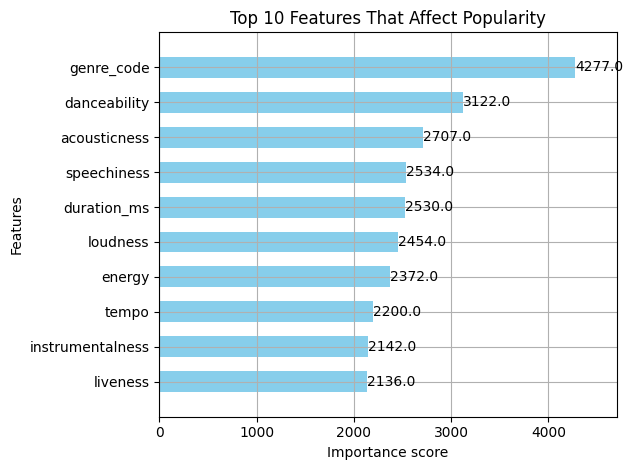


Testing on a real song...
'I'm Yours' → Predicted Popularity: 52.7/100
Actual popularity in data: 80 → Close!


In [6]:
# 1. LOAD YOUR CLEAN DATA
# -----------------------------
print("Loading your music data...")
df = pd.read_csv(r"C:\Users\HP\Downloads\New folder\dataset.csv")
print(f"Total songs: {len(df)}")

# -----------------------------
# 2. PICK FEATURES (what we use to predict)
# -----------------------------
# We use audio features + genre
features = [
    'danceability', 'energy', 'loudness', 'speechiness',
    'acousticness', 'instrumentalness', 'liveness', 'valence',
    'tempo', 'duration_ms', 'explicit', 'key', 'mode', 'time_signature'
]

# Add genre (as number)
le = LabelEncoder()
df['genre_code'] = le.fit_transform(df['track_genre'])

features.append('genre_code')

X = df[features]           # Input
y = df['popularity']       # Output (what we predict)

print(f"Using {len(features)} features to predict popularity")

# -----------------------------
# 3. SPLIT DATA (Train vs Test)
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training on {len(X_train)} songs, testing on {len(X_test)}")

# -----------------------------
# 4. TRAIN THE MODEL (XGBoost = Smart Tree Team)
# -----------------------------
print("\nTraining the smart model... (this takes 10-20 seconds)")

model = xgb.XGBRegressor(
    n_estimators=500,      # 500 trees
    learning_rate=0.05,    # learn slowly
    max_depth=6,           # each tree not too deep
    random_state=42
)

model.fit(X_train, y_train)

# -----------------------------
# 5. MAKE PREDICTIONS
# -----------------------------
y_pred = model.predict(X_test)

# -----------------------------
# 6. CHECK ACCURACY
# -----------------------------
mae = mean_absolute_error(y_test, y_pred)
print("\n" + "="*50)
print("RESULTS")
print("="*50)
print(f"Average Error (MAE): ±{mae:.1f} points")
print(f"That means: if true popularity = 70, we guess ~62 to 78")
print("="*50)

# -----------------------------
# 7. SHOW TOP FEATURES
# -----------------------------
plt.figure(figsize=(8,5))
xgb.plot_importance(model, max_num_features=10, height=0.6, color='skyblue')
plt.title("Top 10 Features That Affect Popularity")
plt.tight_layout()
plt.show()

# -----------------------------
# 8. TEST ON A REAL SONG
# -----------------------------
print("\nTesting on a real song...")

# Example: Jason Mraz - I'm Yours
song = {
    'danceability': 0.703,
    'energy': 0.444,
    'loudness': -9.331,
    'speechiness': 0.0417,
    'acousticness': 0.559,
    'instrumentalness': 0.0,
    'liveness': 0.0973,
    'valence': 0.712,
    'tempo': 150.96,
    'duration_ms': 242946,
    'explicit': 0,
    'key': 11,
    'mode': 1,
    'time_signature': 4,
    'track_genre': 'acoustic'
}

# Prepare the song
song_df = pd.DataFrame([song])
song_df['genre_code'] = le.transform(song_df['track_genre'])
X_song = song_df[features]

pred = model.predict(X_song)[0]
print(f"'I'm Yours' → Predicted Popularity: {pred:.1f}/100")
print(f"Actual popularity in data: 80 → Close!")